In [1]:
import numpy as np
import torch
import torchvision
import json
import torchvision.transforms as transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import sys
sys.path.insert(0, '/pbabkin/main/mipt/nas-for-moe/code/data')
sys.path.insert(0, '/pbabkin/main/mipt/nas-for-moe/code')
sys.path.insert(0, '/pbabkin/main/mipt/nas-for-moe/code/toy_experiment')
import toy_searchspace
import toy_dataset
import toy_graph
import nas_moe.vae
import nas_moe.dataset
import nas_moe.surrogate
import nas_moe.single_arch
import nas_moe.graph
import nas_moe.utils
import importlib

# Перезагрузить конкретные модули
importlib.reload(toy_searchspace)
importlib.reload(toy_dataset)
importlib.reload(toy_graph)
importlib.reload(nas_moe.vae)
importlib.reload(nas_moe.dataset)
importlib.reload(nas_moe.surrogate)
importlib.reload(nas_moe.single_arch)
importlib.reload(nas_moe.graph)
importlib.reload(nas_moe.utils)
import os
from torch.utils.data import DataLoader
from torch_geometric.data import Batch
from pathlib import Path
import torch.nn as nn
from torch.utils.data import DataLoader
from torch_geometric.data import Batch
from tqdm import tqdm
from nni.nas.hub.pytorch import DARTS as DartsSpace
from torch_geometric.utils import dense_to_sparse
import random
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import numpy as np


SEED = 322
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.10/dist-packages/nni/nas/nn/pytorch/layers.py:94: RuntimeWarning: <class 'torch.nn.parameter.Buffer'> is found to be not a nn.Module, which is unexpected. It means your PyTorch version might not be supported.
  warnings.warn(f'{obj} is found to be not a nn.Module, which is unexpected. '


In [2]:
X_combined = np.load('/pbabkin/main/mipt/nas-for-moe/code/toy_experiment/data/data_X.npy')
y_combined = np.load('/pbabkin/main/mipt/nas-for-moe/code/toy_experiment/data/data_y.npy')

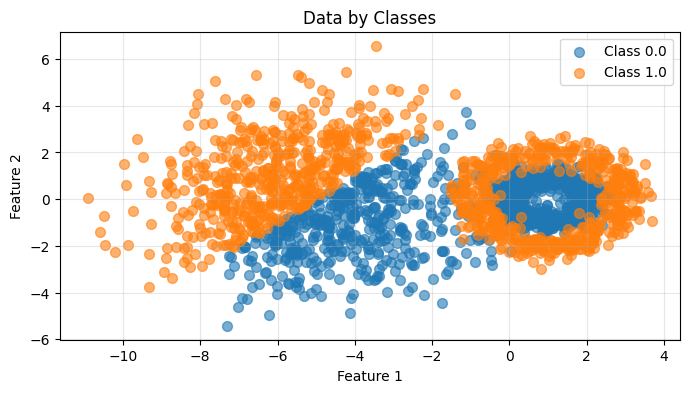

In [3]:
plt.figure(figsize=(8, 4))

for class_label in np.unique(y_combined):
    mask = y_combined == class_label
    plt.scatter(X_combined[mask, 0], X_combined[mask, 1], 
                label=f'Class {class_label}', alpha=0.6, s=50)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data by Classes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_combined)

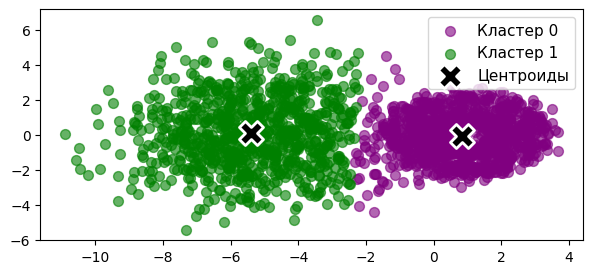

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))

colors_kmeans = ['purple', 'green']
for i in range(n_clusters):
    ax.scatter(X_combined[clusters == i, 0], 
               X_combined[clusters == i, 1], 
               label=f'Кластер {i}', alpha=0.6, s=50, color=colors_kmeans[i])

# Отображаем центроиды
ax.scatter(kmeans.cluster_centers_[:, 0], 
           kmeans.cluster_centers_[:, 1], 
           label='Центроиды', marker='X', s=300, color='black', edgecolors='white', linewidth=2)

ax.legend(fontsize=11)

plt.show()

In [6]:
def train_cell(cell, X_train, y_train, X_test, y_test, epochs=100, lr=0.2, verbose=False):    
    X_train = torch.FloatTensor(X_train)
    y_train = torch.LongTensor(y_train)
    X_test = torch.FloatTensor(X_test)
    y_test = torch.LongTensor(y_test)
    
    optimizer = torch.optim.SGD(cell.parameters(), lr=lr, momentum=0.9, nesterov=True)
    criterion = nn.CrossEntropyLoss()

    batch_size=32
    n_batches = len(X_train) // batch_size
    
    for epoch in range(epochs):
        # Shuffle данных
        indices = torch.randperm(len(X_train))
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        epoch_loss = 0
        for i in range(n_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            
            batch_X = X_train_shuffled[start_idx:end_idx]
            batch_y = y_train_shuffled[start_idx:end_idx]
            
            optimizer.zero_grad()
            outputs = cell(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(cell.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
        
        if (epoch + 1) % 100 == 0:
            with torch.no_grad():
                test_outputs = cell(X_test)
                test_preds = torch.argmax(test_outputs, dim=1)
                test_acc = (test_preds == y_test).float().mean()
            avg_loss = epoch_loss / n_batches
            if verbose:
                print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Test Acc={test_acc:.4f}")
    
    return test_acc.item()

In [7]:
X_train_clusters_list = []
y_train_clusters_list = []
X_test_clusters_list = []
y_test_clusters_list = []

for cluster_id in range(n_clusters):
    mask = (clusters == cluster_id)
    X_cluster = X_combined[mask]
    y_cluster = y_combined[mask]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_cluster, y_cluster, test_size=0.2, random_state=SEED
    )
    
    X_train_clusters_list.append(X_train)
    y_train_clusters_list.append(y_train)
    X_test_clusters_list.append(X_test)
    y_test_clusters_list.append(y_test)

# Collect dataset

In [8]:
ss = toy_searchspace.ToySearchSpace(input_dim=2, num_nodes_per_cell=4)
dataset_dir = '/pbabkin/main/mipt/nas-for-moe/model_dataset'

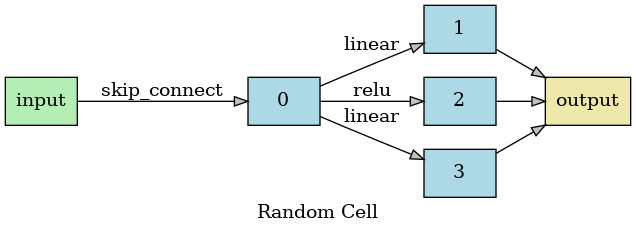

In [9]:
c = ss.create_random_config()
toy_searchspace.plot_single_cell(c)

In [10]:
os.makedirs(dataset_dir, exist_ok=True)
for i in tqdm(range(2045, 3000)):

    total_params = 0
    while total_params == 0:
        c = ss.create_random_config()
        cell = ss.create_cell_from_config(c)
        total_params = sum(p.numel() for p in cell.parameters())


    accs = []
    for cluster_id in range(n_clusters):
        cell = ss.create_cell_from_config(c)
        acc = train_cell(cell,
                   X_train_clusters_list[cluster_id],
                   y_train_clusters_list[cluster_id],
                   X_test_clusters_list[cluster_id],
                   y_test_clusters_list[cluster_id],
                   )
        accs.append(acc)
    data = {
        'arch': c,
        'accuracies': accs
    }

    # Write to JSON file
    with open(f'{dataset_dir}/arch_accs_{i}.json', 'w') as f:
        json.dump(data, f, indent=4)

  0%|▎                                                                                                                                             | 2/955 [00:03<27:35,  1.74s/it]


KeyboardInterrupt: 

In [10]:
base_path = Path(dataset_dir)
model_dicts_paths = [base_path / p for p in sorted(os.listdir(base_path))]

# random.shuffle(model_dicts_paths)

split = int(0.8 * len(model_dicts_paths))
dataset_cluster_acc_train = toy_dataset.ArchClusterACCDatasetBoolVector(
    model_dicts_paths[:split]
)
dataset_cluster_acc_test = toy_dataset.ArchClusterACCDatasetBoolVector(
    model_dicts_paths[split:]
)

def collate_graphs(batch):
    return Batch.from_data_list(batch)

train_loader = DataLoader(
    dataset_cluster_acc_train,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_graphs
)

test_loader = DataLoader(
    dataset_cluster_acc_test,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_graphs
)
# for el in train_loader:
#     print(el.y)
#     break

In [39]:
targets = [[], []]
for el in dataset_cluster_acc_train:
    if torch.equal(el.bool_vector, torch.tensor([[1., 0.]])):
        targets[0].append(el.y)
    else:
        targets[1].append(el.y)
targets[0] = torch.cat(targets[0], dim=0)
targets[1] = torch.cat(targets[1], dim=0)
mean_0, mean_1 = targets[0].mean(), targets[1].mean()

print(f"Shape: {targets[0].shape}")
print(f"Shape: {targets[1].shape}")
print(f"Mean: {mean_0}")
print(f"Mean: {mean_1}")

targets = [[], []]
for el in dataset_cluster_acc_test:
    if torch.equal(el.bool_vector, torch.tensor([[1., 0.]])):
        targets[0].append(el.y)
    else:
        targets[1].append(el.y)
targets[0] = torch.cat(targets[0], dim=0)
targets[1] = torch.cat(targets[1], dim=0)

mse_baseline0 = ((targets[0] - mean_0)**2).mean()
mse_baseline1 = ((targets[1] - mean_1)**2).mean()
print(targets[0].mean(), mse_baseline1)
(mse_baseline0 + mse_baseline1) / 2

Shape: torch.Size([2400, 1])
Shape: torch.Size([2400, 1])
Mean: 0.5789324641227722
Mean: 0.6912635564804077
tensor(0.5797) tensor(0.0385)


tensor(0.0235)

In [ ]:
targets = []
for el in dataset_cluster_acc_train:
    targets.append(el.y)
# targets = torch.stack(targets)

targets = torch.cat(targets, dim=0)  # Объединить все [1, C] в [N, C]
mean_targets_train = targets.mean(dim=0)    # Mean по всем примерам → [C]

print(f"Shape: {targets.shape}")
print(f"Mean: {mean_targets_train}")

targets = []
for el in dataset_cluster_acc_test:
    targets.append(el.y)

targets_test = torch.cat(targets, dim=0)

print(f"Shape: {targets_test.shape}")

mse_baseline = ((targets_test - mean_targets_train)**2).mean()
mse_baseline

Shape: torch.Size([2400, 2])
Mean: tensor([0.5789, 0.6913])
Shape: torch.Size([600, 2])


tensor(0.0235)

In [40]:
surr = nas_moe.surrogate.GAT_Datafeature(7, 1, 0.8, hidden_dim=8, heads=1, bool_vec_size=2)

In [41]:
def evaluate_surrogate(surr: torch.nn.Module, loader: torch.utils.data.DataLoader, device: str = "cpu",
                       criterion: torch.nn.Module = None) -> float:
    """Вычисляет средний loss на loader (набор батчей Data)."""
    if criterion is None:
        criterion = torch.nn.MSELoss()
    surr.to(device)
    surr.eval()
    total_loss = 0.0
    n_batches = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = surr(batch.x, batch.edge_index, batch.batch, batch.bool_vector)
            loss = criterion(out, batch.y)
            total_loss += loss.item()
            n_batches += 1
    return total_loss / max(1, n_batches)


def train_surrogate_with_val(surr: torch.nn.Module,
                             train_loader: torch.utils.data.DataLoader,
                             test_loader: torch.utils.data.DataLoader = None,
                             device: str = "cpu",
                             lr: float = 1e-3,
                             epochs: int = 50,
                             weight_decay: float = 0.0,
                             checkpoint_path: str = None,
                             verbose: bool = False) -> dict:
    """
    Тренировочный цикл для surrogate GNN с логированием train/val loss и отрисовкой графиков.

    Возвращает history = {'train': [...], 'test': [...]}.
    """
    optimizer = torch.optim.Adam(surr.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.MSELoss()
    history = {'train': [], 'test': []}
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2,
        eta_min=lr * 0.01
    )

    surr.to(device)
    if verbose:
        iterator = range(1, epochs + 1)
    else:
        iterator = tqdm(range(1, epochs + 1), desc="Training surrogate")
    for epoch in iterator:
        surr.train()
        train_loss = 0.0
        n_batches = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = surr(batch.x, batch.edge_index, batch.batch, batch.bool_vector)
            loss = criterion(out, batch.y)
            # print(batch.y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            n_batches += 1
        train_loss /= max(1, n_batches)
        test_loss = None
        if test_loader is not None:
            test_loss = evaluate_surrogate(surr, test_loader, device, criterion)

        history['train'].append(train_loss)
        history['test'].append(test_loss if test_loss is not None else float('nan'))

        scheduler.step()

        if verbose:
            if test_loss is not None:
                print(f"Epoch {epoch}/{epochs}  train_loss={train_loss:.6f}  test_loss={test_loss:.6f}")
            else:
                print(f"Epoch {epoch}/{epochs}  train_loss={train_loss:.6f}")

        if checkpoint_path:
            torch.save({'epoch': epoch, 'model_state': surr.state_dict(),
                        'optimizer_state': optimizer.state_dict()}, checkpoint_path)

    return history

In [ ]:
surr.to(device)

history = train_surrogate_with_val(surr, train_loader=train_loader, test_loader=test_loader,
                                       device=device, epochs=120,
                                       lr=0.003, weight_decay=1e-5)
print(history['train'][-1])
print(history['test'][-1])

Training surrogate:   0%|                                                                                                                                  | 0/150 [00:00<?, ?it/s]

Training surrogate: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [03:35<00:00,  1.43s/it]

0.02131348477055629
0.017277968091596114


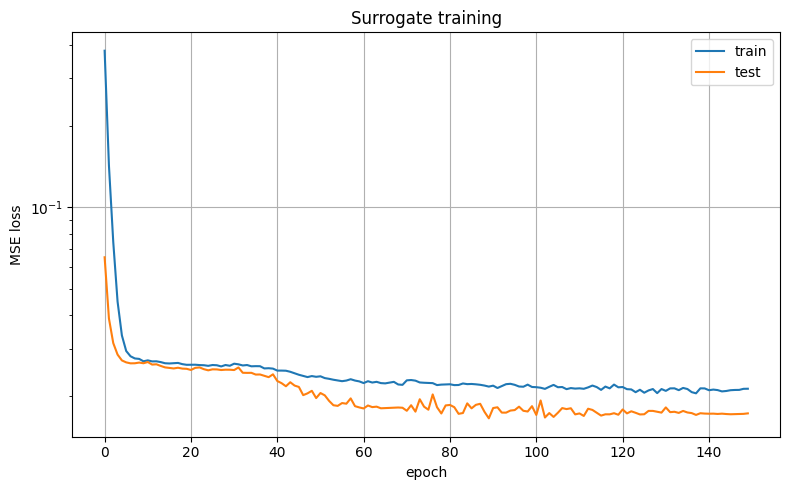

In [43]:
nas_moe.utils.plot_training_history(history)

In [45]:
# surr.cpu()
# n = 7
# print('predictions:  ', nas_moe.utils.inference_one(surr, dataset_cluster_acc_test[n]).data)
# print('ground truth: ', dataset_cluster_acc_test[n].y)
# print('mean:         ', mean_targets_train)